# K-W test across radiomics features

In [8]:
import pandas as pd


def merged_csv(dir_path):
    all_csvs = glob.glob(os.path.join(dir_path, "*", "*spine_vertebrae*.csv"))
    csv_dict = defaultdict(list)
    result_dict = {}
    for file in all_csvs:
        csv_name = os.path.basename(file)
        csv_dict[csv_name].append(file)

    for csv_name, files in csv_dict.items():
        dfs = []
        for file in files:
            df = pd.read_csv(file)
            patient_name = os.path.basename(os.path.dirname(file))
            df.insert(0, "patient", patient_name)
            dfs.append(df)

        key_name = csv_name.replace("_radiomics_spine_vertebrae_features.csv", "")
        big_df = pd.concat(dfs, ignore_index=True)
        result_dict[key_name] = big_df
    return result_dict

In [2]:
from scipy.stats import kruskal
import numpy as np

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]

all_csvs = merged_csv(r"E:\DATA_Myelomy")
for name, radiomic_df in all_csvs.items():
    print(f"Processing: {name}")

    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')
    numeric_features_image = radiomic_df.select_dtypes(include=['number']).columns

    kruskal_wallis = {}
    for radiomic_col in numeric_features_image:
        data_subset = merged_df[[radiomic_col, "ISS classification"]].dropna()
        groups = [
            group[radiomic_col].values
            for _, group in data_subset.groupby("ISS classification")
        ]

        groups = [g for g in groups if len(g) > 1]

        if len(groups) < 2:
            continue

        all_values = np.concatenate(groups)
        if np.all(all_values == all_values[0]):
            continue

        try:
            stat, p_value = kruskal(*groups)
            kruskal_wallis[radiomic_col] = {'stat': stat, 'p_value': p_value}
        except ValueError:
            continue

    kruskal_wallis_df = pd.DataFrame(kruskal_wallis).T
    kruskal_wallis_df = kruskal_wallis_df.sort_values(by='stat', ascending=False)
    print(f"Significant features: {(kruskal_wallis_df['p_value'] < 0.05).sum()}")
    print(kruskal_wallis_df.head(10))
    print("-" * 50)

Processing: BMD
Significant features: 19
                                                         stat   p_value
original_firstorder_Energy                          11.794678  0.002747
original_firstorder_TotalEnergy                     11.169427  0.003755
gradient_ngtdm_Coarseness                            9.570853  0.008351
original_shape_VoxelVolume                           9.261451  0.009748
gradient_glrlm_RunLengthNonUniformity                9.175249  0.010177
original_shape_MeshVolume                            9.116191  0.010482
original_glrlm_RunLengthNonUniformity                8.514791  0.014159
original_gldm_LargeDependenceHighGrayLevelEmphasis   8.165730  0.016859
gradient_gldm_DependenceNonUniformity                8.016547  0.018165
original_shape_SurfaceVolumeRatio                    7.315546  0.025790
--------------------------------------------------
Processing: CaSupp_25
Significant features: 36
                                            stat   p_value
original_f

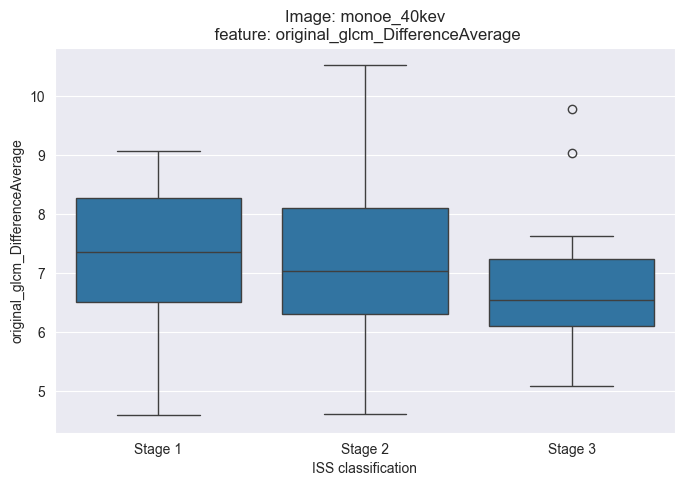

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

image = "monoe_40kev"
feature = "original_glcm_DifferenceAverage"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

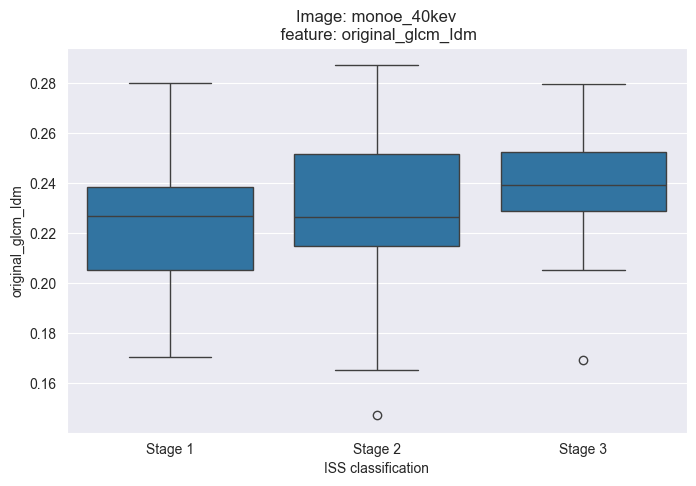

In [4]:
image = "monoe_40kev"
feature = "original_glcm_Idm"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

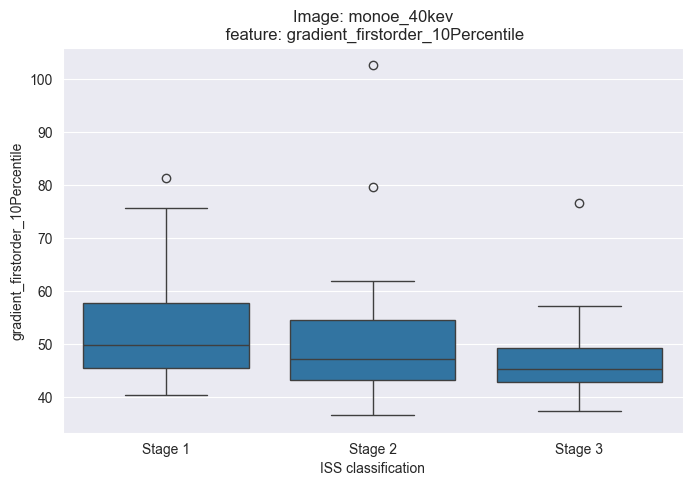

In [5]:
image = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

# HEALTHY FOLLOW-UP

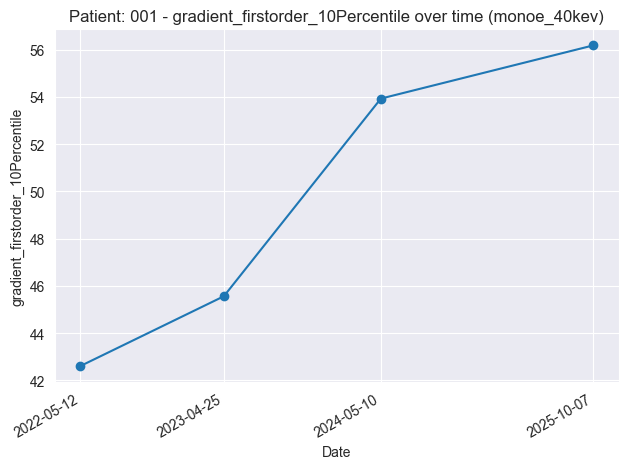

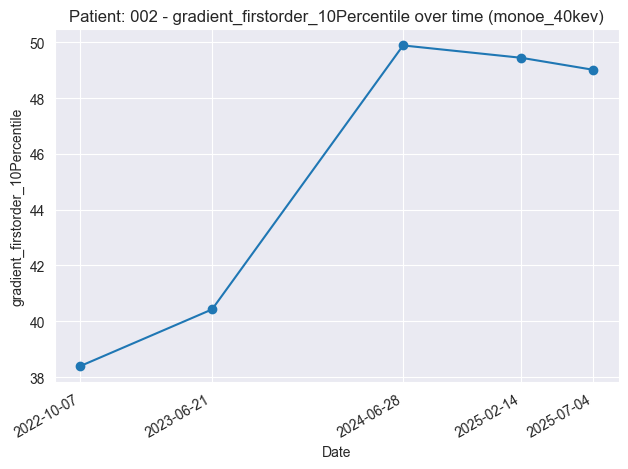

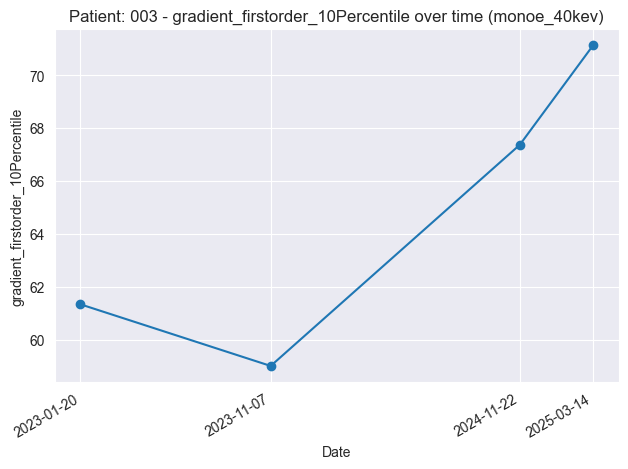

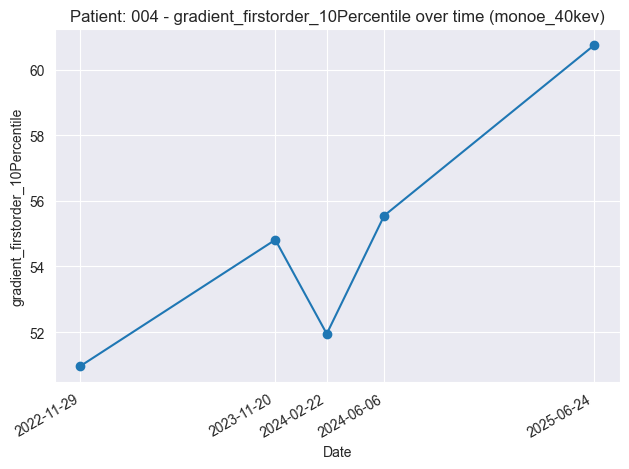

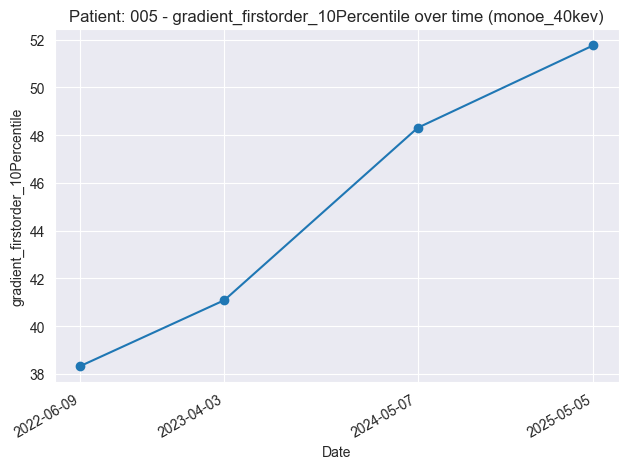

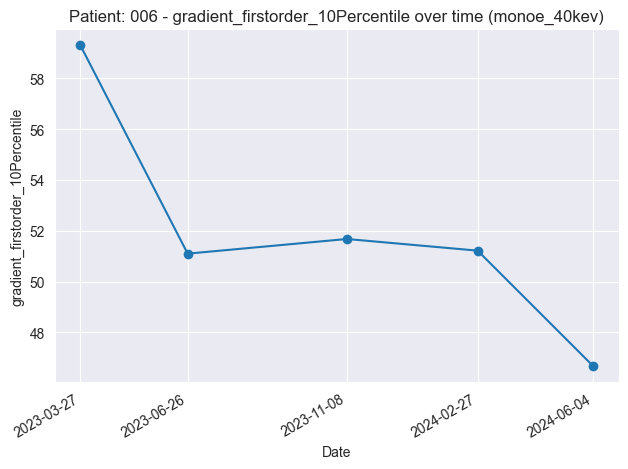

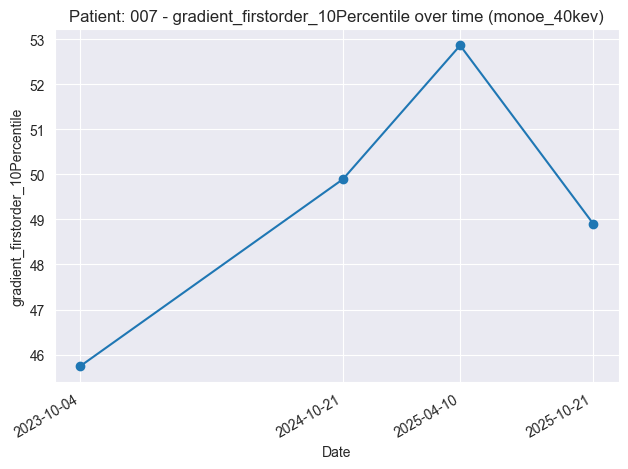

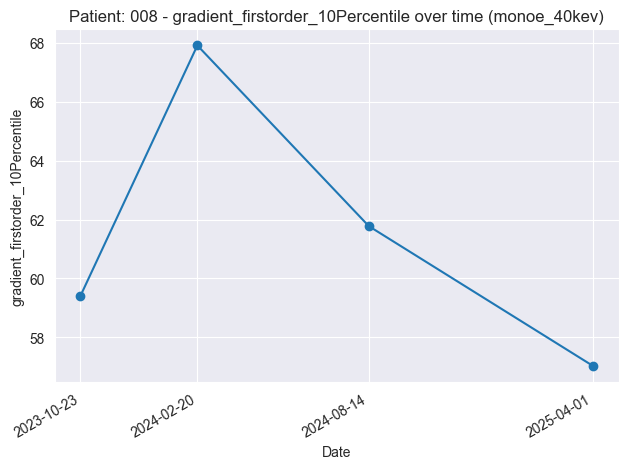

In [6]:
import os
import re
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt


main_folder_path = r"E:\DATA_FollowUp"

image_types = ["CaSupp_25", "konv", "monoe_40kev"]
patients = {img: defaultdict(list) for img in image_types}

pattern = r"Myel_FollowUp_(\d+)_(\d+)"

for folder in os.listdir(main_folder_path):
    match = re.match(pattern, folder)
    if match:
        patient_id = match.group(1)
        followup_number = int(match.group(2))

        folder_path = os.path.join(main_folder_path, folder)
        for file in os.listdir(folder_path):
            if file.endswith(".csv") and "spine_vertebrae" in file:
                for img in image_types:
                    if img in file:
                        csv_path = os.path.join(folder_path, file)
                        patients[img][patient_id].append((followup_number, csv_path))

patient_dates = {
    "001": ["12-05-2022", "25-04-2023", "10-05-2024", "07-10-2025"],
    "002": ["07-10-2022", "21-06-2023", "28-06-2024", "14-02-2025", "04-07-2025"],
    "003": ["20-01-2023", "07-11-2023", "22-11-2024", "14-03-2025"],
    "004": ["29-11-2022", "20-11-2023", "22-02-2024", "06-06-2024", "24-06-2025"],
    "005": ["09-06-2022", "03-04-2023", "07-05-2024", "05-05-2025"],
    "006": ["27-03-2023", "26-06-2023", "08-11-2023", "27-02-2024", "04-06-2024"],
    "007": ["04-10-2023", "21-10-2024", "10-04-2025", "21-10-2025"],
    "008": ["23-10-2023", "20-02-2024", "14-08-2024", "01-04-2025"],
}

patient_follow_up_dfs = {}

for img_type, patient_data in patients.items():
    patient_follow_up_dfs[img_type] = {}

    for patient, scans in patient_data.items():
        scans = sorted(scans, key=lambda x: x[0])
        dfs = []
        for followup, path in scans:
            df = pd.read_csv(path)
            dfs.append(df)

        patient_df = pd.concat(dfs, ignore_index=True)
        patient_df.insert(0, "Date", patient_dates[patient])
        patient_follow_up_dfs[img_type][patient] = patient_df

image_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")
    plt.plot(df["Date"], df[feature], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

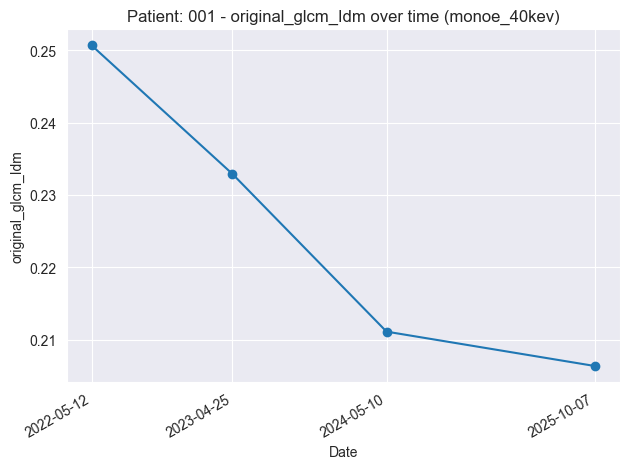

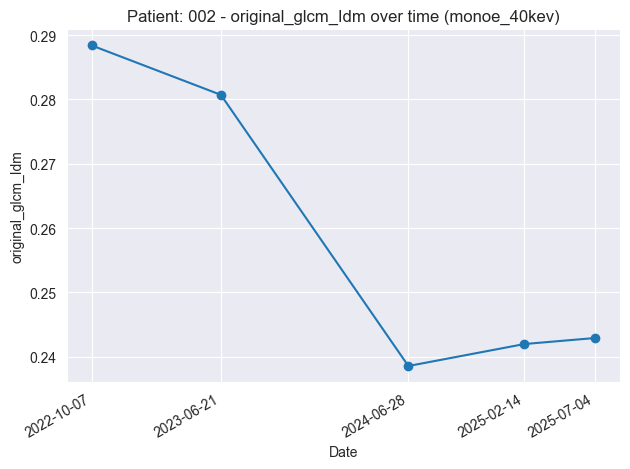

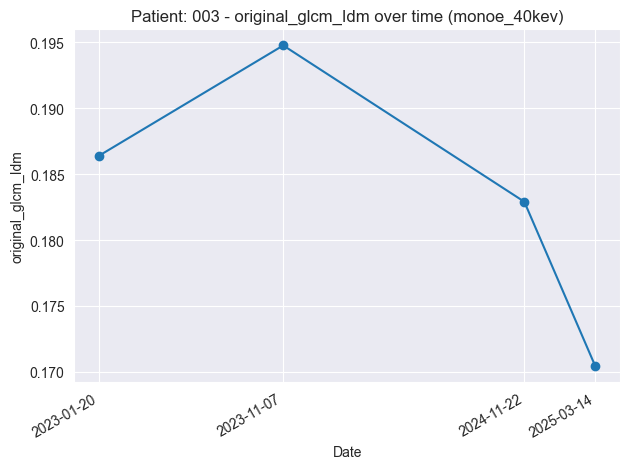

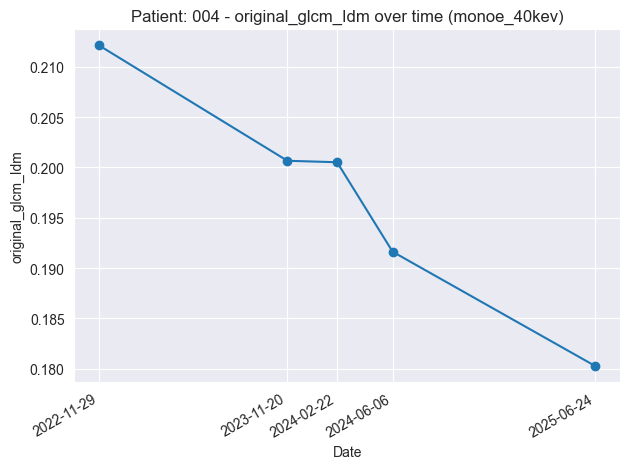

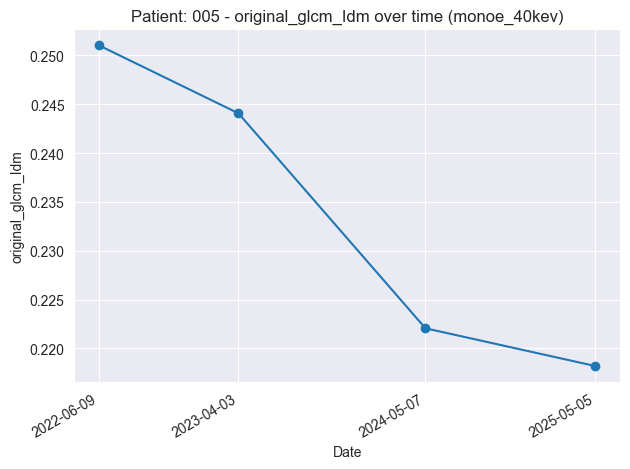

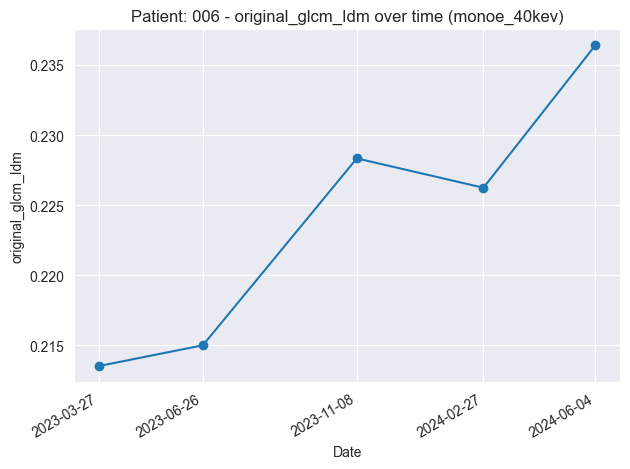

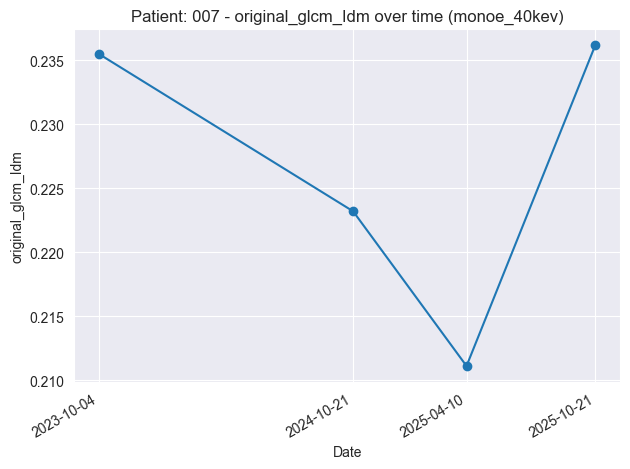

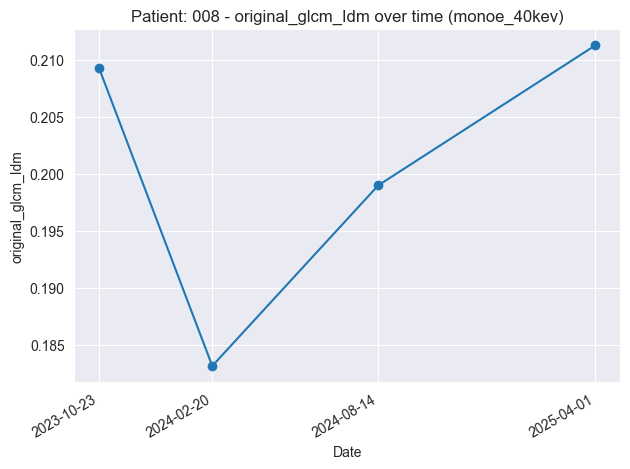

In [7]:
image_type = "monoe_40kev"
feature = "original_glcm_Idm"

for patient, df in patient_follow_up_dfs[image_type].items():
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date")
    plt.plot(df["Date"], df[feature], marker="o")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} over time ({image_type})")
    plt.xticks(df["Date"], df["Date"].dt.strftime("%Y-%m-%d"))
    plt.grid(True)
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

Zobraziť zdrave vs leze v jednom grafe - boxploty

In [9]:
import os
import glob
from collections import defaultdict

def merged_csv(dir_path):
    all_csvs = glob.glob(os.path.join(dir_path, "**", "*spine*.csv"), recursive=True)

    csv_dict = defaultdict(list)
    result_dict = {}

    suffixes = {
        "_radiomics_spine_vertebrae_features.csv": "vertebrae",
        "_radiomics_spine_lesions_features.csv": "lesions"
    }

    for file in all_csvs:
        csv_name = os.path.basename(file)

        # Overíme, či súbor patrí do jednej z našich kategórií
        for suffix in suffixes:
            if csv_name.endswith(suffix):
                csv_dict[csv_name].append(file)
                break

    for csv_name, files in csv_dict.items():
        dfs = []

        # Určíme kategóriu (vertebrae/lesions) a základný názov (napr. monoe_40kev)
        category = ""
        base_name = csv_name
        for suffix, cat_label in suffixes.items():
            if csv_name.endswith(suffix):
                category = cat_label
                base_name = csv_name.replace(suffix, "")
                break

        for file in files:
            try:
                df = pd.read_csv(file)
                # Získame meno pacienta z názvu nadradeného priečinka
                patient_name = os.path.basename(os.path.dirname(file))
                df.insert(0, "patient", patient_name)
                dfs.append(df)
            except Exception as e:
                print(f"Chyba pri načítaní {file}: {e}")

        if dfs:
            # Vytvoríme unikátny kľúč, napr. "monoe_40kev_lesions"
            key_name = f"{base_name}_{category}"
            big_df = pd.concat(dfs, ignore_index=True)
            result_dict[key_name] = big_df

    return result_dict

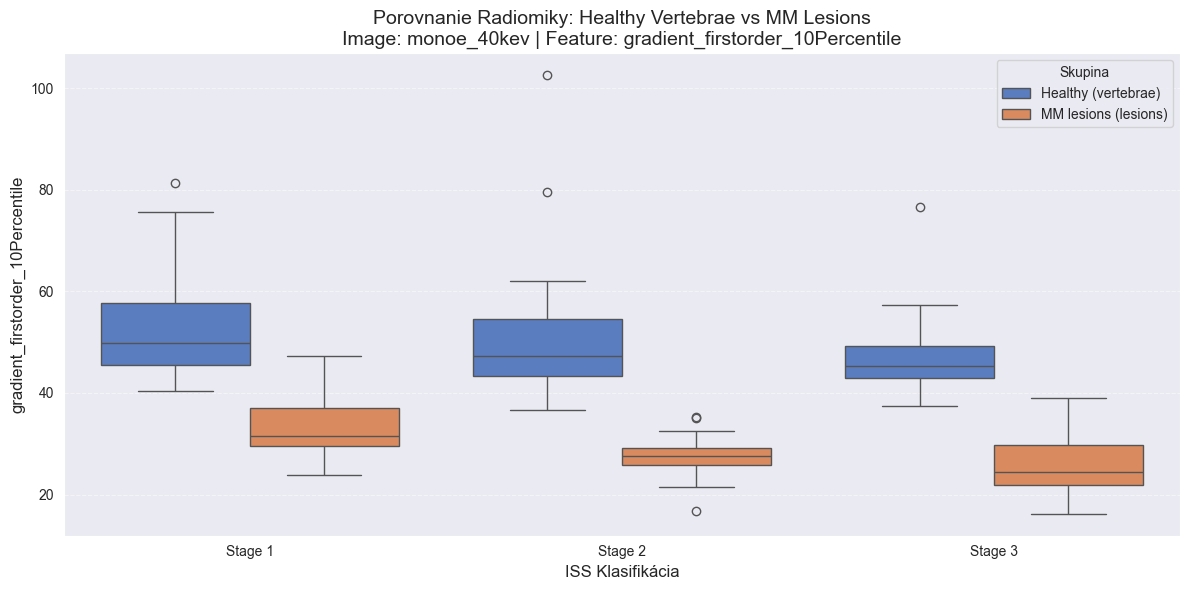

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

all_datasets = merged_csv(r"E:\DATA_Myelomy")

# 2. Nastavenia pre vizualizáciu
image = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

# 3. Príprava dát pre vertebrae (Healthy)
# Kľúč v slovníku je vytvorený tvojou funkciou: {image}_vertebrae
if f"{image}_vertebrae" in all_datasets:
    df_v = all_datasets[f"{image}_vertebrae"].copy()
    # Prepojenie s klinickými dátami (clinical_df musí existovať v pamäti)
    merged_v = pd.merge(df_v, clinical_df, left_on='patient', right_on='Patient ID')
    merged_v['Dataset Type'] = 'Healthy (vertebrae)'
else:
    print(f"Chyba: Dáta pre {image}_vertebrae sa nenašli.")
    merged_v = pd.DataFrame()

# 4. Príprava dát pre lesions (MM lesions)
# Kľúč v slovníku: {image}_lesions
if f"{image}_lesions" in all_datasets:
    df_l = all_datasets[f"{image}_lesions"].copy()
    merged_l = pd.merge(df_l, clinical_df, left_on='patient', right_on='Patient ID')
    merged_l['Dataset Type'] = 'MM lesions (lesions)'
else:
    print(f"Chyba: Dáta pre {image}_lesions sa nenašli.")
    merged_l = pd.DataFrame()

# 5. Spojenie oboch pripravených tabuliek do jednej pre Seaborn
if not merged_v.empty and not merged_l.empty:
    combined_df = pd.concat([merged_v, merged_l], ignore_index=True)

    # 6. Vykreslenie boxplotov
    plt.figure(figsize=(12, 6))

    # Použijeme 'hue' na rozlíšenie Healthy vs Lesions
    sns.boxplot(
        data=combined_df,
        x="ISS classification",
        y=feature,
        hue="Dataset Type",
        palette="muted",
        showfliers=True  # Zobrazí outliery ako bodky
    )

    # Pridanie názvu a popisov
    plt.title(f"Porovnanie Radiomiky: Healthy Vertebrae vs MM Lesions\nImage: {image} | Feature: {feature}", fontsize=14)
    plt.xlabel("ISS Klasifikácia", fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

    # Úprava legendy
    plt.legend(title="Skupina", loc="upper right")

    plt.tight_layout()
    plt.show()
else:
    print("Nedostatok dát na vykreslenie porovnania.")

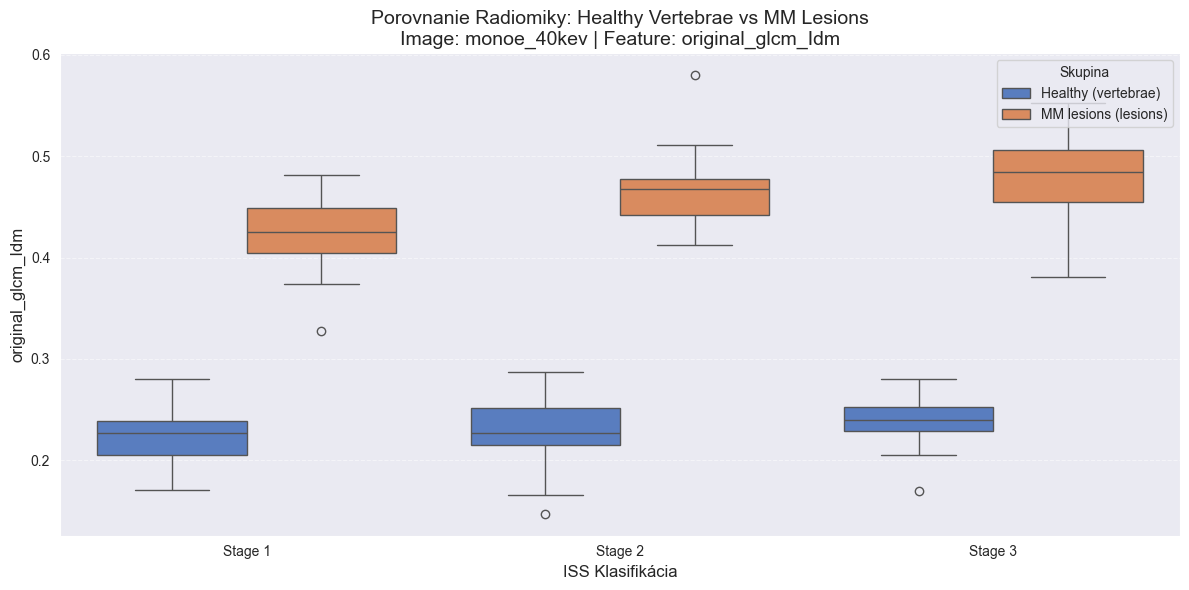

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

all_datasets = merged_csv(r"E:\DATA_Myelomy")

# 2. Nastavenia pre vizualizáciu
image = "monoe_40kev"
feature = "original_glcm_Idm"

# 3. Príprava dát pre vertebrae (Healthy)
# Kľúč v slovníku je vytvorený tvojou funkciou: {image}_vertebrae
if f"{image}_vertebrae" in all_datasets:
    df_v = all_datasets[f"{image}_vertebrae"].copy()
    # Prepojenie s klinickými dátami (clinical_df musí existovať v pamäti)
    merged_v = pd.merge(df_v, clinical_df, left_on='patient', right_on='Patient ID')
    merged_v['Dataset Type'] = 'Healthy (vertebrae)'
else:
    print(f"Chyba: Dáta pre {image}_vertebrae sa nenašli.")
    merged_v = pd.DataFrame()

# 4. Príprava dát pre lesions (MM lesions)
# Kľúč v slovníku: {image}_lesions
if f"{image}_lesions" in all_datasets:
    df_l = all_datasets[f"{image}_lesions"].copy()
    merged_l = pd.merge(df_l, clinical_df, left_on='patient', right_on='Patient ID')
    merged_l['Dataset Type'] = 'MM lesions (lesions)'
else:
    print(f"Chyba: Dáta pre {image}_lesions sa nenašli.")
    merged_l = pd.DataFrame()

# 5. Spojenie oboch pripravených tabuliek do jednej pre Seaborn
if not merged_v.empty and not merged_l.empty:
    combined_df = pd.concat([merged_v, merged_l], ignore_index=True)

    # 6. Vykreslenie boxplotov
    plt.figure(figsize=(12, 6))

    # Použijeme 'hue' na rozlíšenie Healthy vs Lesions
    sns.boxplot(
        data=combined_df,
        x="ISS classification",
        y=feature,
        hue="Dataset Type",
        palette="muted",
        showfliers=True  # Zobrazí outliery ako bodky
    )

    # Pridanie názvu a popisov
    plt.title(f"Porovnanie Radiomiky: Healthy Vertebrae vs MM Lesions\nImage: {image} | Feature: {feature}", fontsize=14)
    plt.xlabel("ISS Klasifikácia", fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

    # Úprava legendy
    plt.legend(title="Skupina", loc="upper right")

    plt.tight_layout()
    plt.show()
else:
    print("Nedostatok dát na vykreslenie porovnania.")

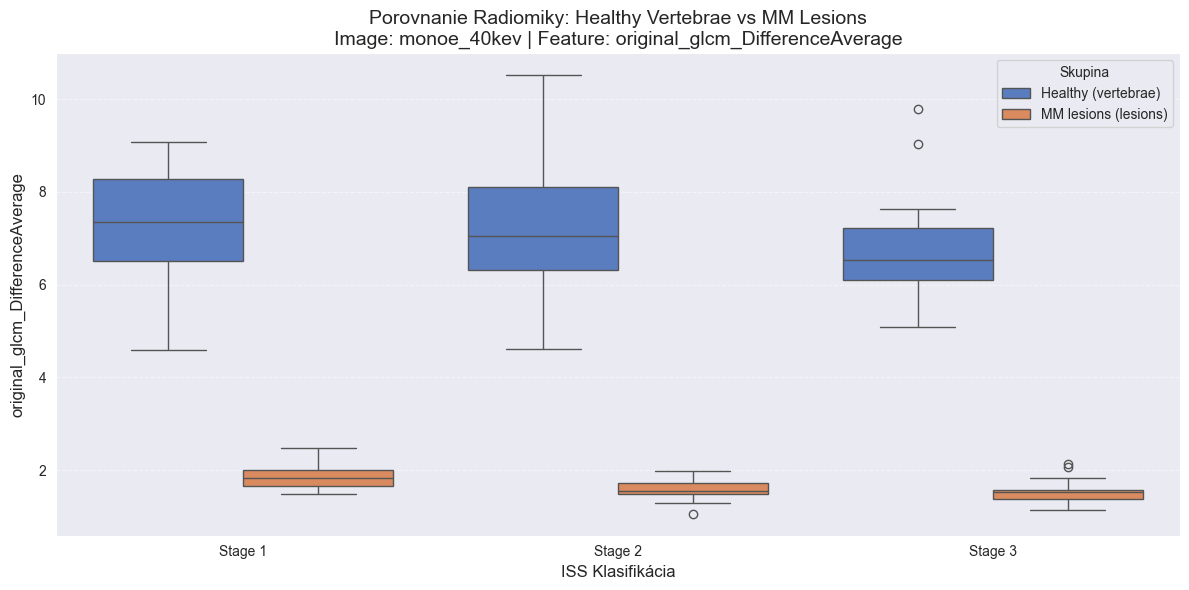

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

all_datasets = merged_csv(r"E:\DATA_Myelomy")

# 2. Nastavenia pre vizualizáciu
image = "monoe_40kev"
feature = "original_glcm_DifferenceAverage"

# 3. Príprava dát pre vertebrae (Healthy)
# Kľúč v slovníku je vytvorený tvojou funkciou: {image}_vertebrae
if f"{image}_vertebrae" in all_datasets:
    df_v = all_datasets[f"{image}_vertebrae"].copy()
    # Prepojenie s klinickými dátami (clinical_df musí existovať v pamäti)
    merged_v = pd.merge(df_v, clinical_df, left_on='patient', right_on='Patient ID')
    merged_v['Dataset Type'] = 'Healthy (vertebrae)'
else:
    print(f"Chyba: Dáta pre {image}_vertebrae sa nenašli.")
    merged_v = pd.DataFrame()

# 4. Príprava dát pre lesions (MM lesions)
# Kľúč v slovníku: {image}_lesions
if f"{image}_lesions" in all_datasets:
    df_l = all_datasets[f"{image}_lesions"].copy()
    merged_l = pd.merge(df_l, clinical_df, left_on='patient', right_on='Patient ID')
    merged_l['Dataset Type'] = 'MM lesions (lesions)'
else:
    print(f"Chyba: Dáta pre {image}_lesions sa nenašli.")
    merged_l = pd.DataFrame()

# 5. Spojenie oboch pripravených tabuliek do jednej pre Seaborn
if not merged_v.empty and not merged_l.empty:
    combined_df = pd.concat([merged_v, merged_l], ignore_index=True)

    # 6. Vykreslenie boxplotov
    plt.figure(figsize=(12, 6))

    # Použijeme 'hue' na rozlíšenie Healthy vs Lesions
    sns.boxplot(
        data=combined_df,
        x="ISS classification",
        y=feature,
        hue="Dataset Type",
        palette="muted",
        showfliers=True  # Zobrazí outliery ako bodky
    )

    # Pridanie názvu a popisov
    plt.title(f"Porovnanie Radiomiky: Healthy Vertebrae vs MM Lesions\nImage: {image} | Feature: {feature}", fontsize=14)
    plt.xlabel("ISS Klasifikácia", fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

    # Úprava legendy
    plt.legend(title="Skupina", loc="upper right")

    plt.tight_layout()
    plt.show()
else:
    print("Nedostatok dát na vykreslenie porovnania.")

Leze + zdravych pacientov do jedného grafu - followup krivky

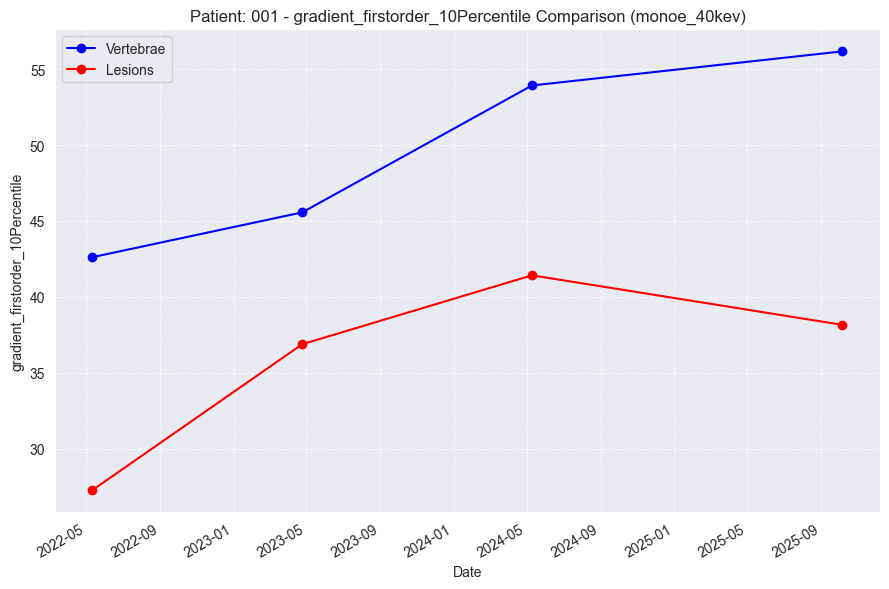

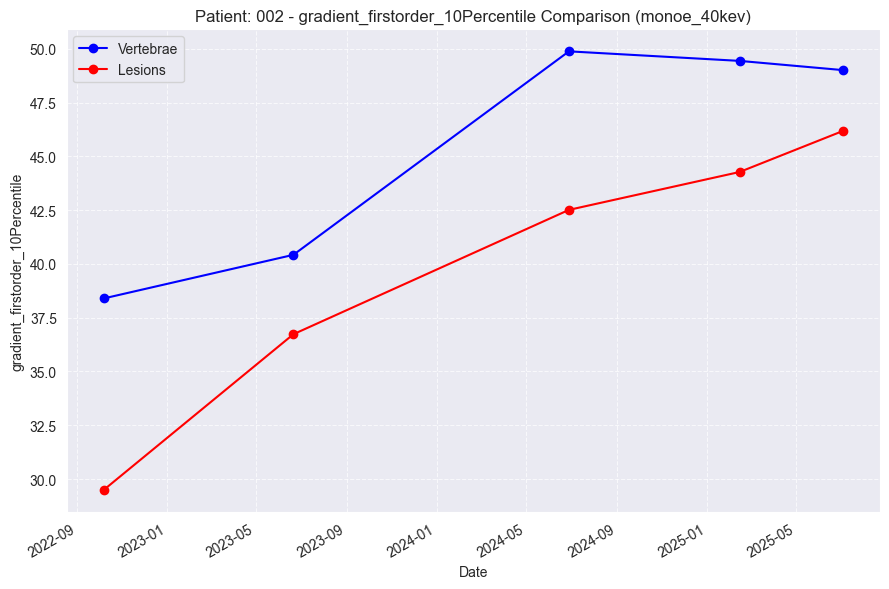

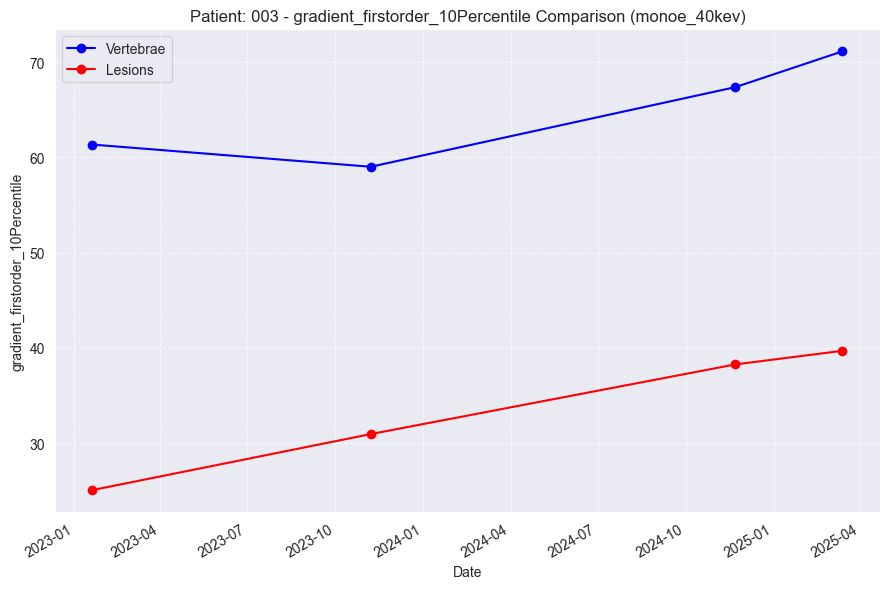

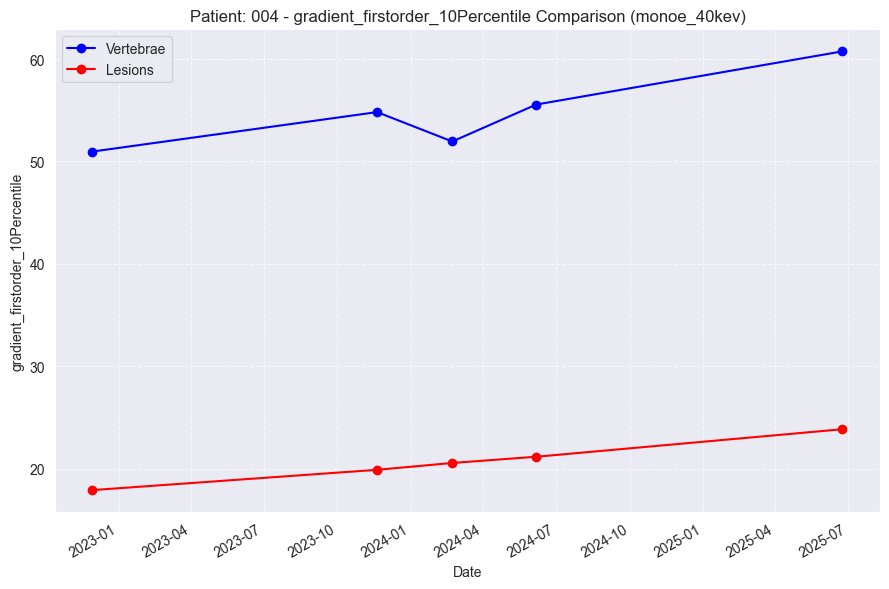

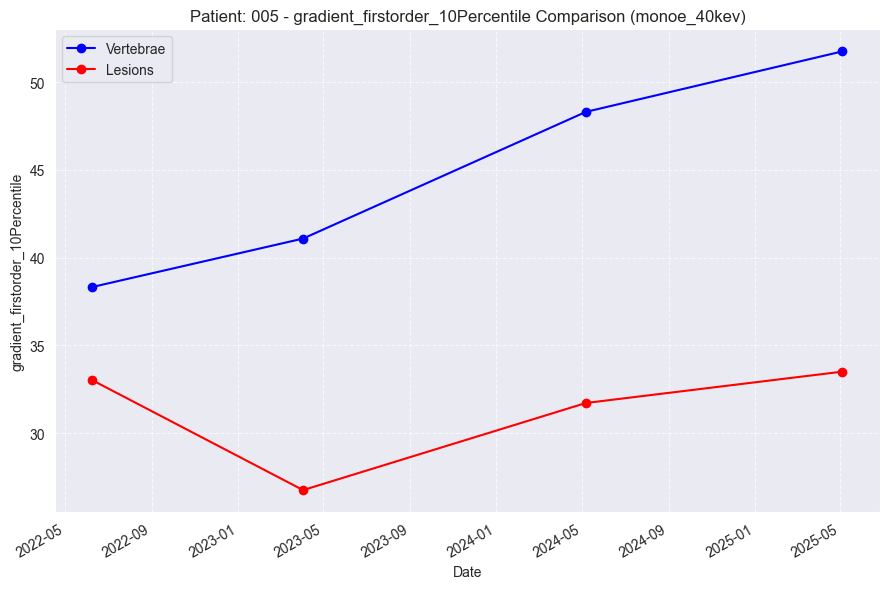

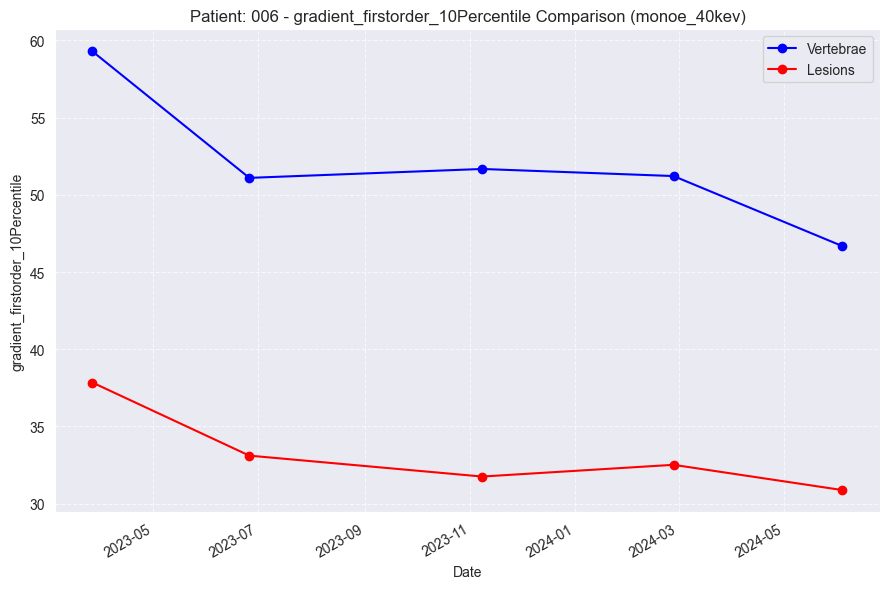

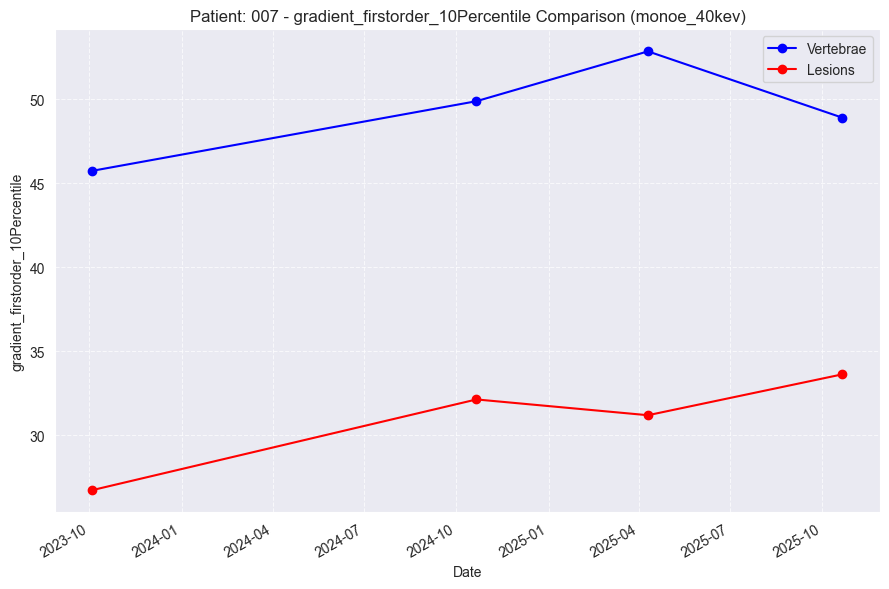

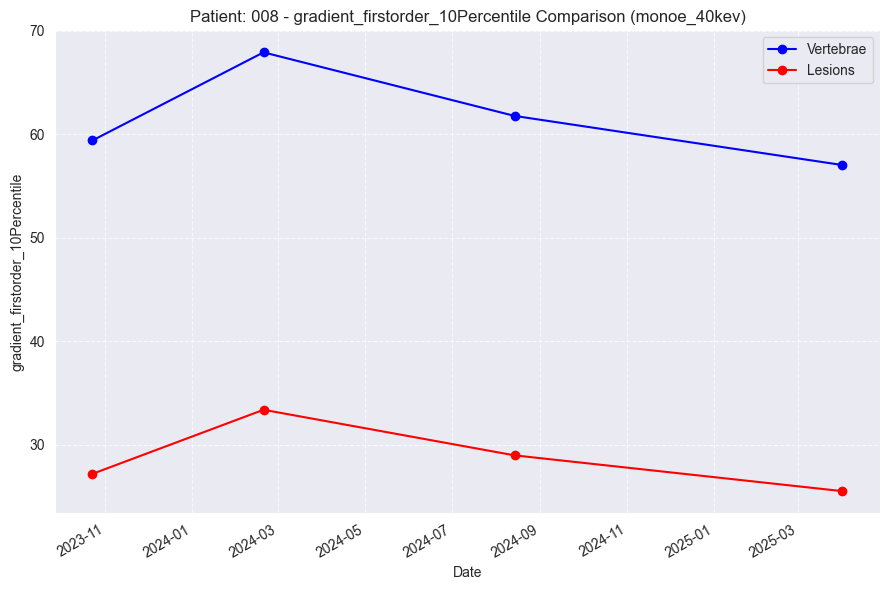

In [1]:
import os
import re
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

main_folder_path = r"E:\DATA_FollowUp"
image_types = ["CaSupp_25", "konv", "monoe_40kev"]
# Zoznam zdrojov, ktoré chceme sledovať
sources = ["spine_vertebrae", "spine_lesions"]

# Upravená štruktúra: patients[img_type][source][patient_id]
patients = {img: {src: defaultdict(list) for src in sources} for img in image_types}

pattern = r"Myel_FollowUp_(\d+)_(\d+)"

# 1. NAČÍTANIE CIEST K SÚBOROM
for folder in os.listdir(main_folder_path):
    match = re.match(pattern, folder)
    if match:
        patient_id = match.group(1)
        followup_number = int(match.group(2))
        folder_path = os.path.join(main_folder_path, folder)

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                for src in sources:
                    if src in file:
                        for img in image_types:
                            if img in file:
                                csv_path = os.path.join(folder_path, file)
                                patients[img][src][patient_id].append((followup_number, csv_path))

# (Tvoje dátumy zostávajú rovnaké)
patient_dates = {
    "001": ["12-05-2022", "25-04-2023", "10-05-2024", "07-10-2025"],
    "002": ["07-10-2022", "21-06-2023", "28-06-2024", "14-02-2025", "04-07-2025"],
    "003": ["20-01-2023", "07-11-2023", "22-11-2024", "14-03-2025"],
    "004": ["29-11-2022", "20-11-2023", "22-02-2024", "06-06-2024", "24-06-2025"],
    "005": ["09-06-2022", "03-04-2023", "07-05-2024", "05-05-2025"],
    "006": ["27-03-2023", "26-06-2023", "08-11-2023", "27-02-2024", "04-06-2024"],
    "007": ["04-10-2023", "21-10-2024", "10-04-2025", "21-10-2025"],
    "008": ["23-10-2023", "20-02-2024", "14-08-2024", "01-04-2025"],
}

# 2. SPRACOVANIE DATAFRAMEOV
patient_follow_up_dfs = {img: {src: {} for src in sources} for img in image_types}

for img_type in image_types:
    for src in sources:
        for patient, scans in patients[img_type][src].items():
            scans = sorted(scans, key=lambda x: x[0])
            dfs = []
            for followup, path in scans:
                df = pd.read_csv(path)
                # Ak má CSV viac riadkov, tu by bolo fajn spraviť medián/priemer,
                # ale držím sa tvojej logiky, že počet riadkov sedí s počtom dátumov.
                dfs.append(df)

            if dfs:
                patient_df = pd.concat(dfs, ignore_index=True)
                # Ošetrenie, ak by počet riadkov nesedel s počtom dátumov v zozname
                dates_to_add = patient_dates[patient][:len(patient_df)]
                patient_df.insert(0, "Date", dates_to_add)
                patient_follow_up_dfs[img_type][src][patient] = patient_df

# 3. VYKRESLENIE DO JEDNÉHO GRAFU
image_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

# Získame unikátny zoznam všetkých pacientov naprieč oboma zdrojmi
all_patients = set(patient_follow_up_dfs[image_type]["spine_vertebrae"].keys()) | \
               set(patient_follow_up_dfs[image_type]["spine_lesions"].keys())

for patient in sorted(all_patients):
    plt.figure(figsize=(9, 6))

    # Skúsime vykresliť obe krivky, ak existujú
    for src, label, color in [("spine_vertebrae", "Vertebrae", "blue"),
                               ("spine_lesions", "Lesions", "red")]:

        if patient in patient_follow_up_dfs[image_type][src]:
            df = patient_follow_up_dfs[image_type][src][patient].copy()
            df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
            df = df.sort_values("Date")

            plt.plot(df["Date"], df[feature], marker="o", label=label, color=color)

    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} Comparison ({image_type})")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

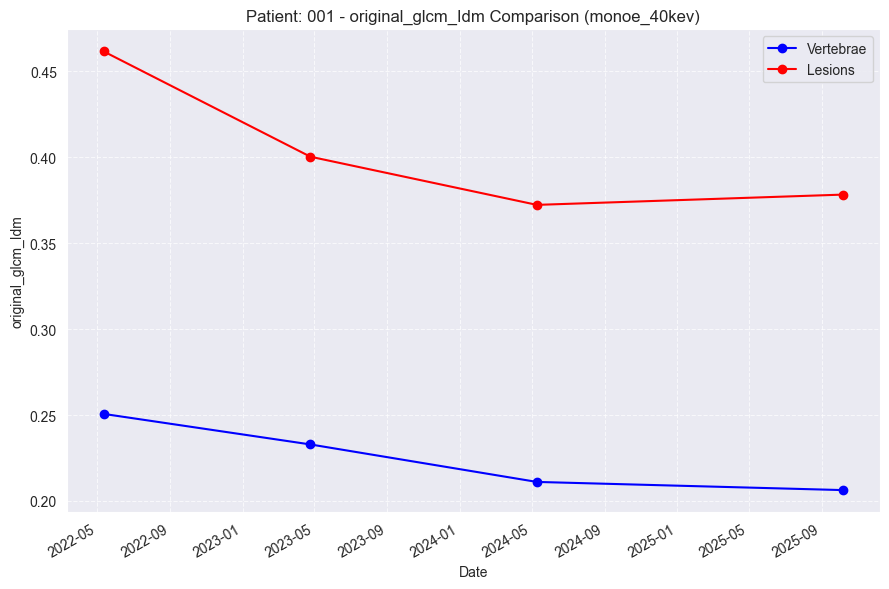

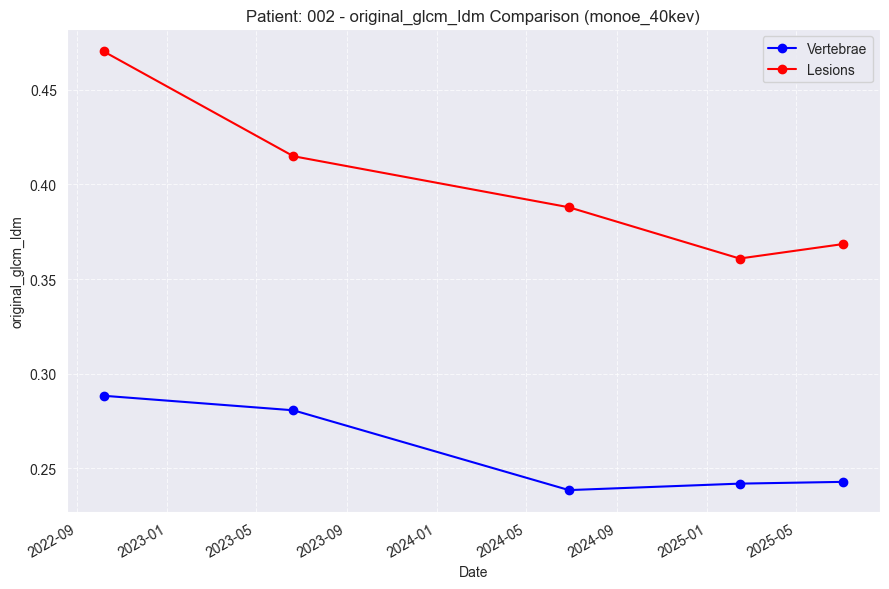

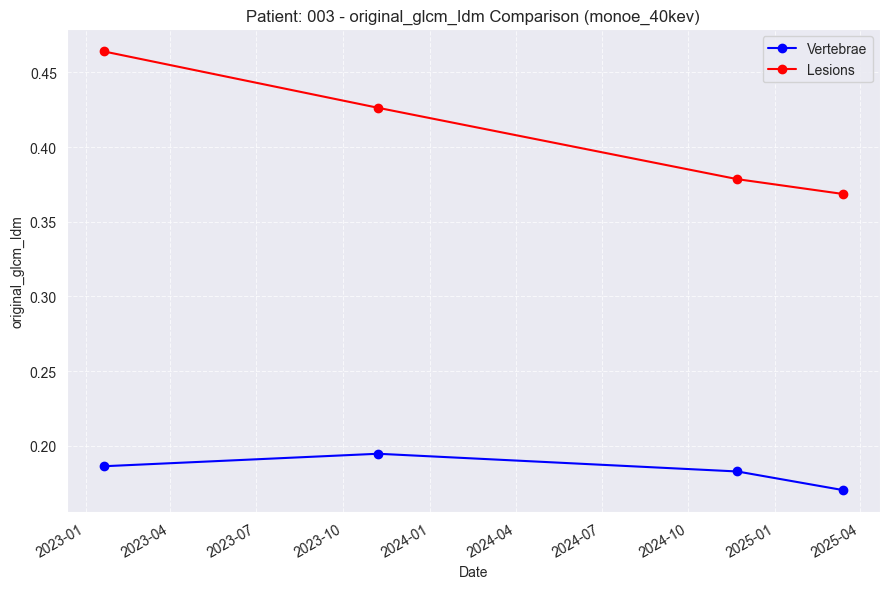

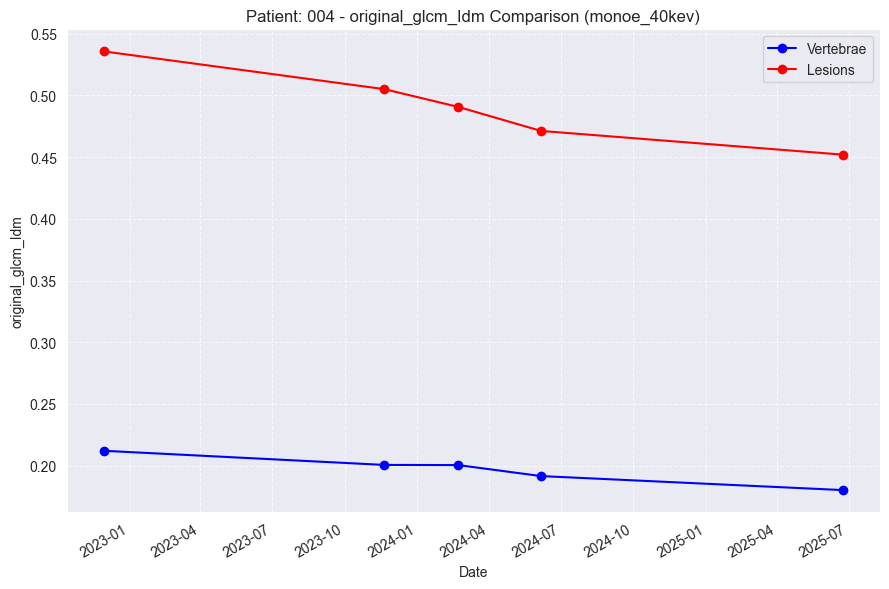

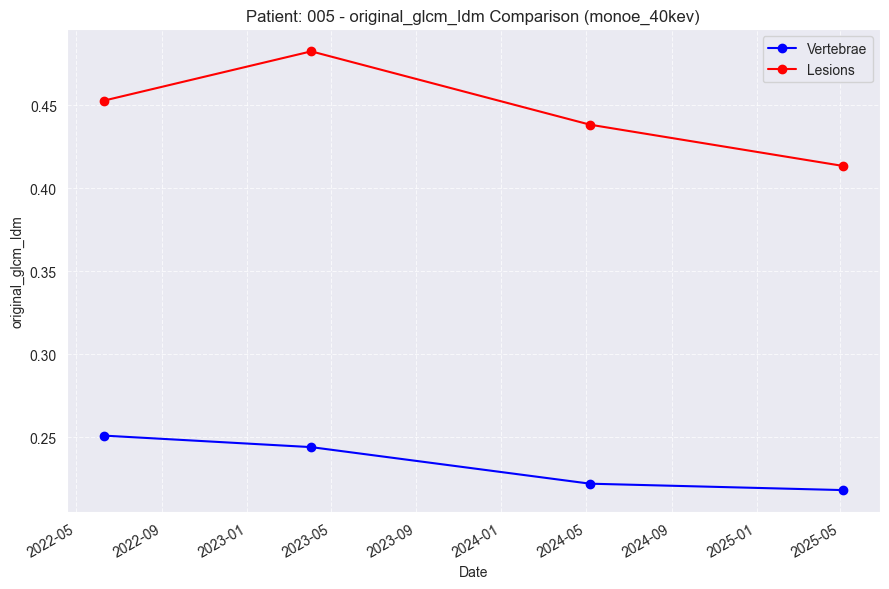

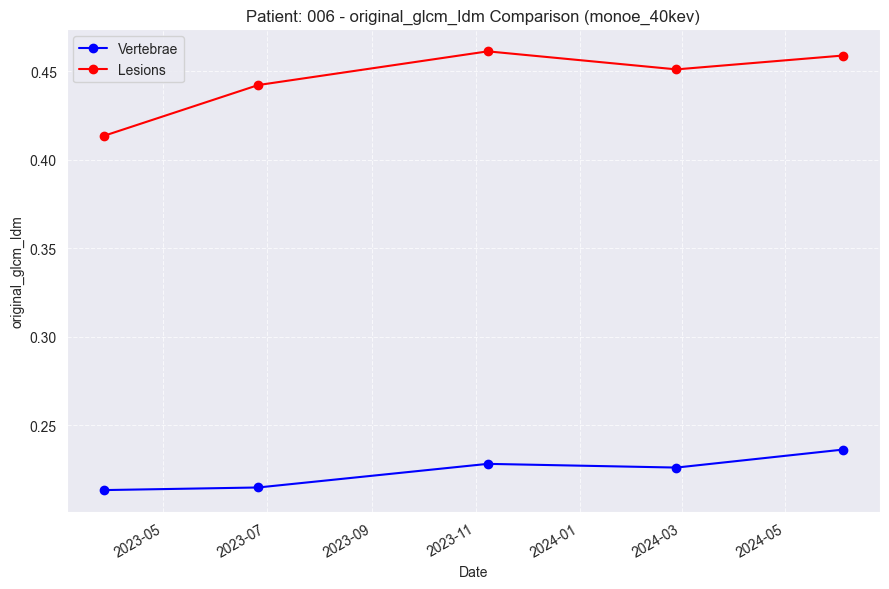

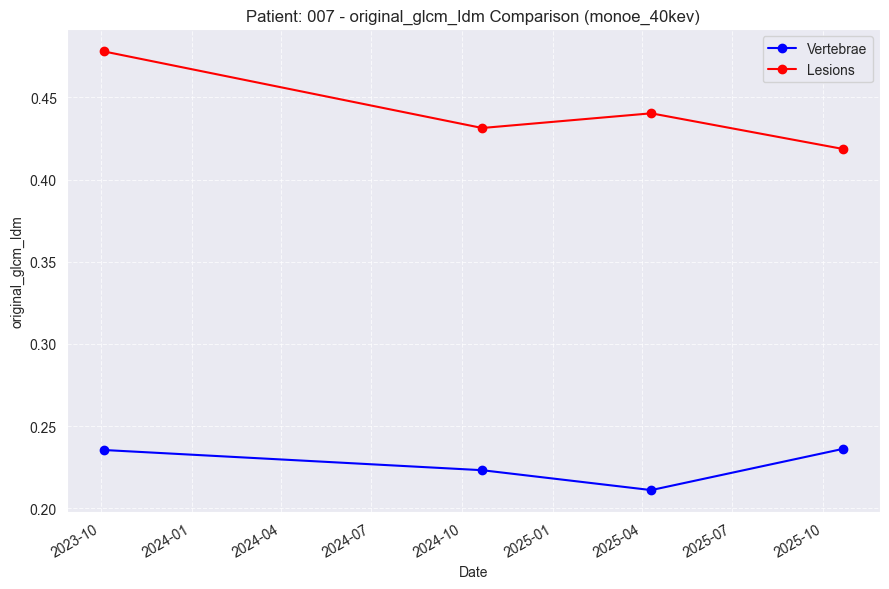

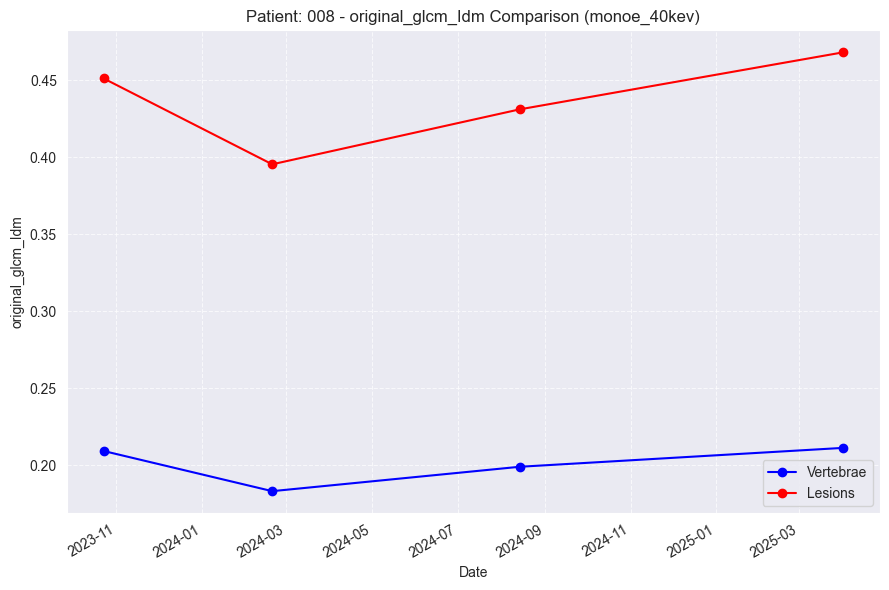

In [16]:
image_type = "monoe_40kev"
feature = "original_glcm_Idm"

# Získame unikátny zoznam všetkých pacientov naprieč oboma zdrojmi
all_patients = set(patient_follow_up_dfs[image_type]["spine_vertebrae"].keys()) | \
               set(patient_follow_up_dfs[image_type]["spine_lesions"].keys())

for patient in sorted(all_patients):
    plt.figure(figsize=(9, 6))

    # Skúsime vykresliť obe krivky, ak existujú
    for src, label, color in [("spine_vertebrae", "Vertebrae", "blue"),
                               ("spine_lesions", "Lesions", "red")]:

        if patient in patient_follow_up_dfs[image_type][src]:
            df = patient_follow_up_dfs[image_type][src][patient].copy()
            df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
            df = df.sort_values("Date")

            plt.plot(df["Date"], df[feature], marker="o", label=label, color=color)

    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.title(f"Patient: {patient} - {feature} Comparison ({image_type})")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

štandardizace leze a zdrave a vykresliť

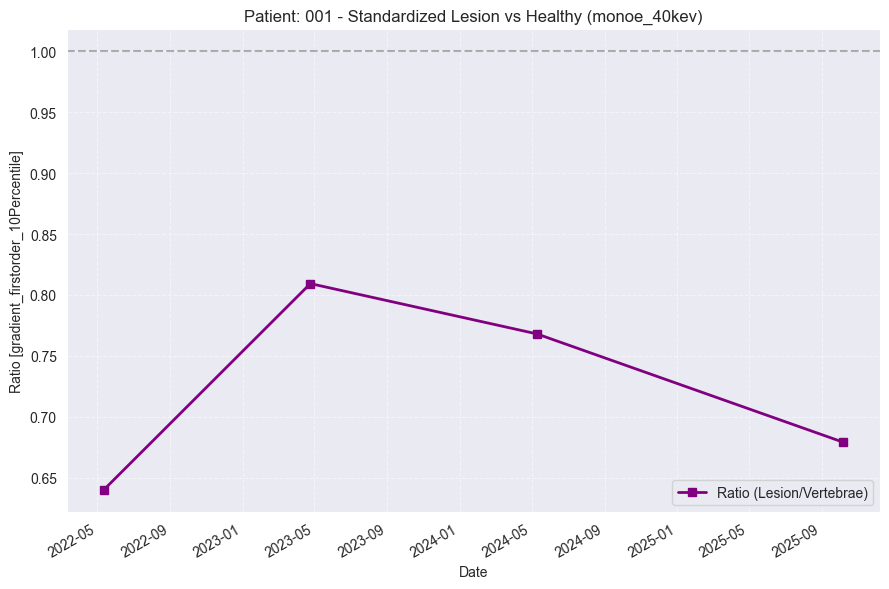

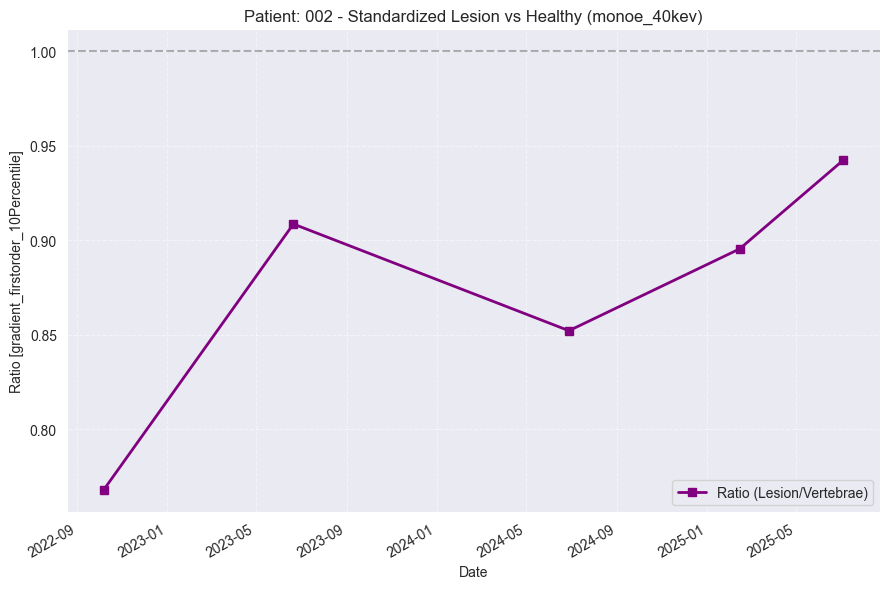

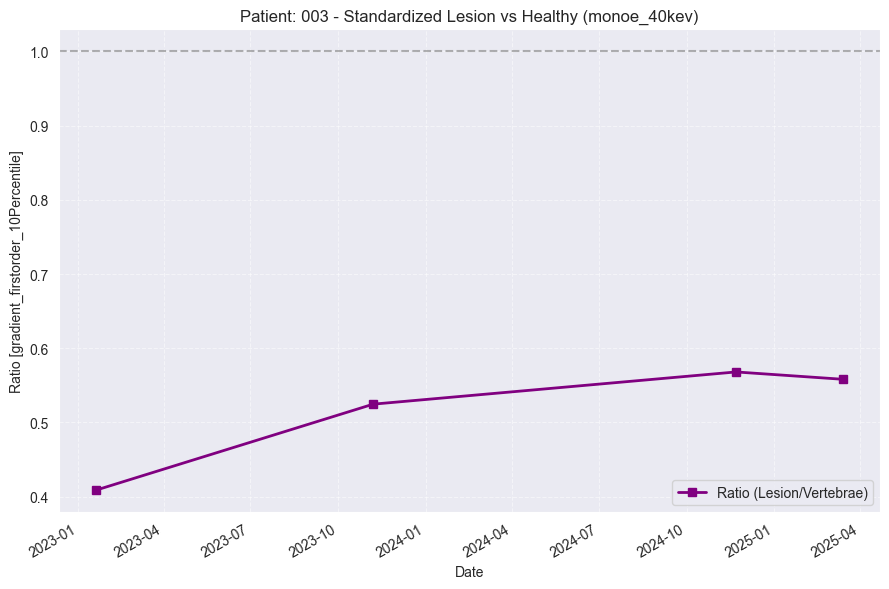

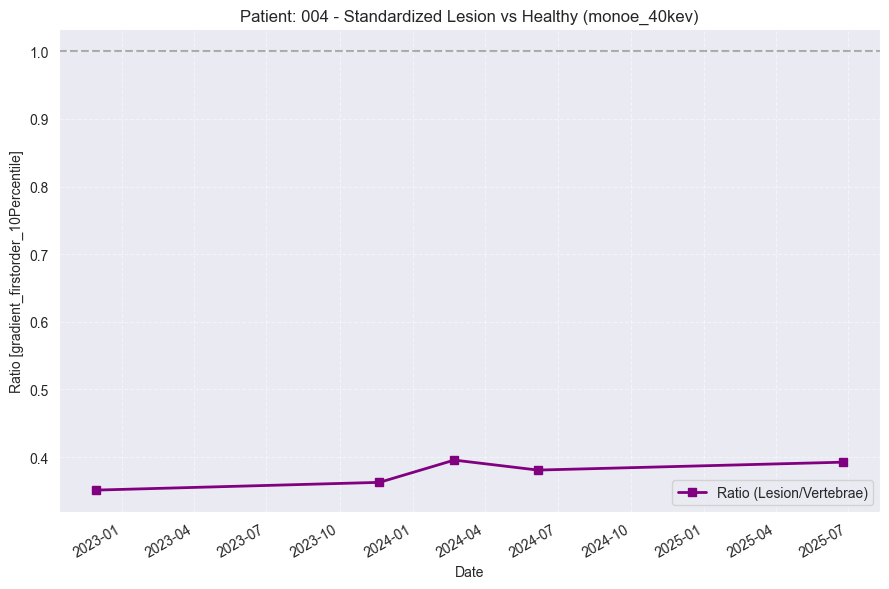

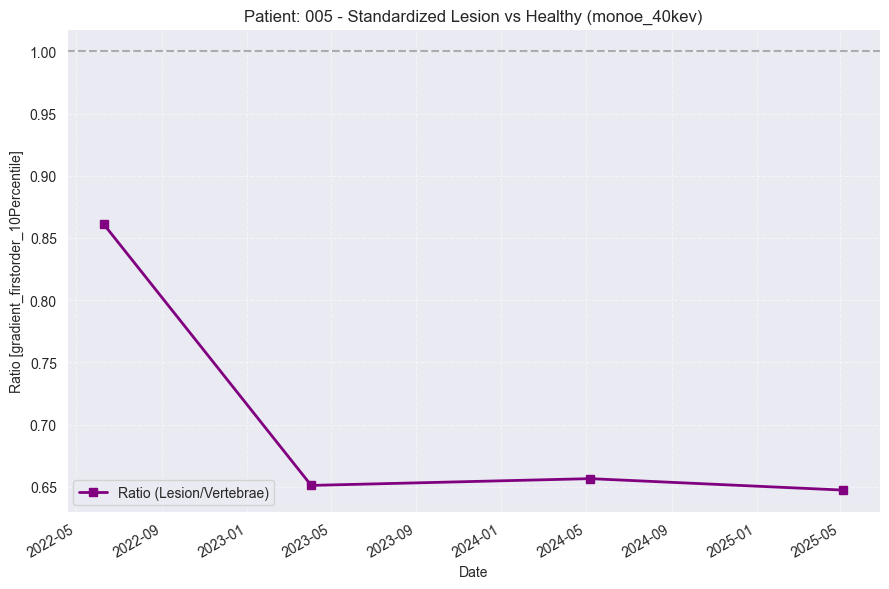

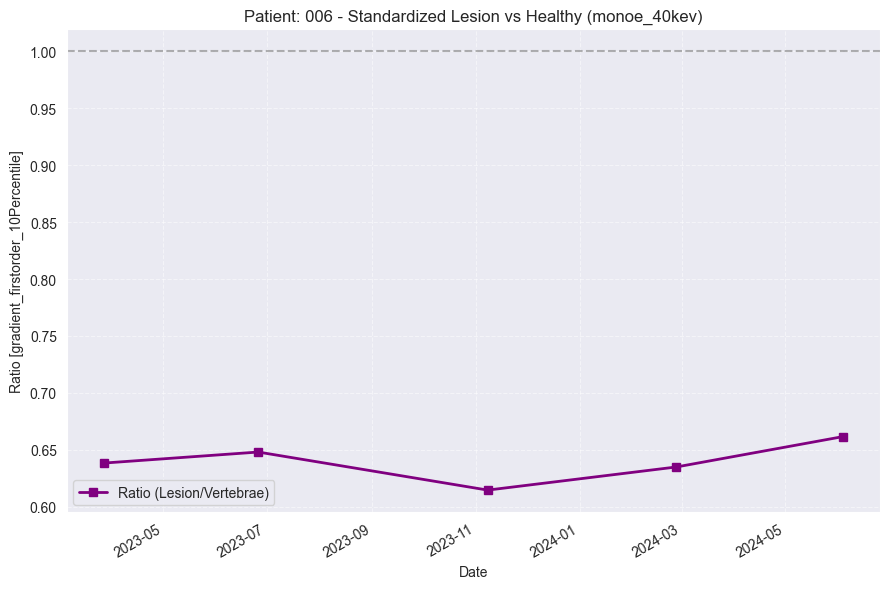

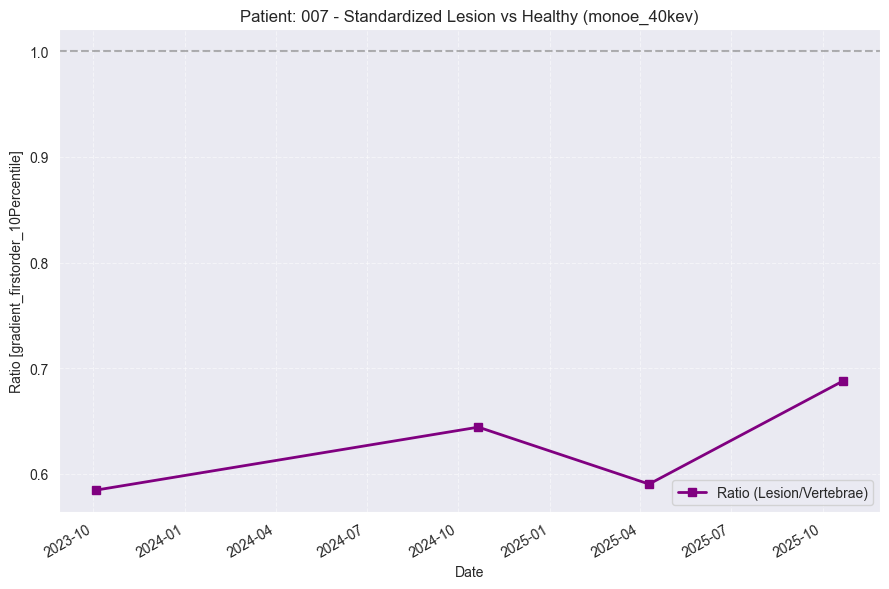

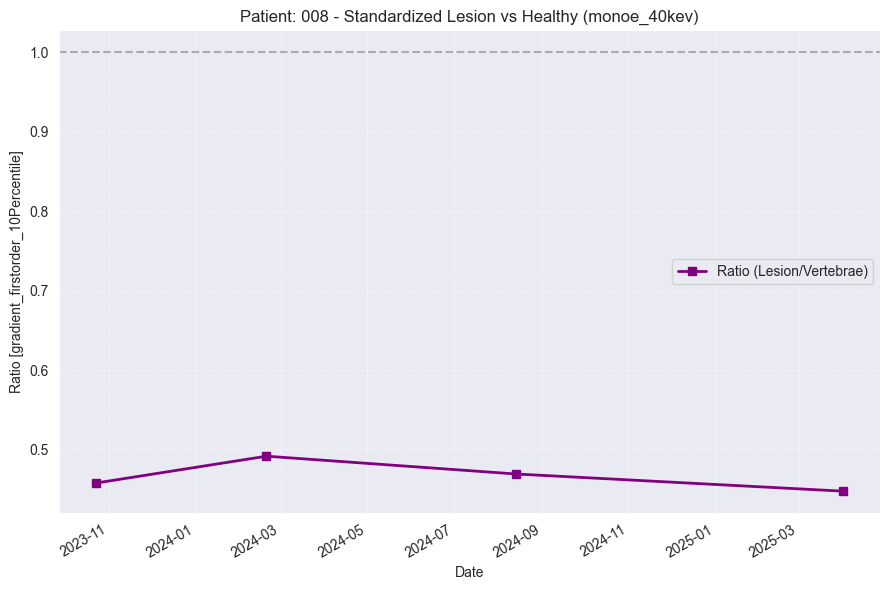

In [2]:
# 3. VYKRESLENIE POMERU (Lézia / Stavec)
image_type = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

# Získame zoznam pacientov, ktorí majú dáta v oboch zdrojoch (inak nevieme deliť)
common_patients = set(patient_follow_up_dfs[image_type]["spine_vertebrae"].keys()) & \
                  set(patient_follow_up_dfs[image_type]["spine_lesions"].keys())

for patient in sorted(common_patients):
    # 1. Príprava dát pre stavce a lézie
    df_vert = patient_follow_up_dfs[image_type]["spine_vertebrae"][patient].copy()
    df_les  = patient_follow_up_dfs[image_type]["spine_lesions"][patient].copy()

    # Prevod dátumov na datetime pre korektné spájanie
    df_vert["Date"] = pd.to_datetime(df_vert["Date"], dayfirst=True)
    df_les["Date"]  = pd.to_datetime(df_les["Date"], dayfirst=True)

    # 2. Spojenie dát podľa dátumu (inner join zabezpečí, že zostanú len dni, kde sú obe merania)
    # suffixy pomôžu rozlíšiť stĺpce po spojení
    merged = pd.merge(df_les, df_vert, on="Date", suffixes=('_lesion', '_vertebrae'))

    if not merged.empty:
        # 3. VÝPOČET POMERU (Štandardizácia)
        # Pomer: Hodnota v lézii / Hodnota v zdravom stavci
        ratio_col_name = f"{feature}_ratio"
        merged[ratio_col_name] = merged[f"{feature}_lesion"] / merged[f"{feature}_vertebrae"]

        # Zoradenie podľa dátumu pre peknú krivku
        merged = merged.sort_values("Date")

        # 4. VYKRESLENIE
        plt.figure(figsize=(9, 6))
        plt.plot(merged["Date"], merged[ratio_col_name],
                 marker="s", linestyle="-", color="purple", linewidth=2,
                 label=f"Ratio (Lesion/Vertebrae)")

        # Pridanie horizontálnej čiary na úrovni 1.0 (ak je pomer 1, lézia = stavec)
        plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6)

        plt.xlabel("Date")
        plt.ylabel(f"Ratio [{feature}]")
        plt.title(f"Patient: {patient} - Standardized Lesion vs Healthy ({image_type})")

        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()

        plt.gcf().autofmt_xdate()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Pacient {patient} nemá prekrývajúce sa dátumy pre lézie a stavce.")